In [1]:
import re
import pandas as pd

In [3]:
f = open('_chat.txt', 'r', encoding='utf-8')

In [7]:
data = f.read()

In [9]:
print(data)

[03/02/26, 09:09:34] Zarsh 3: imissyou
[03/02/26, 10:18:22] Safia ahmad: Missyoutoo
‎[03/02/26, 10:18:23] Safia ahmad: ‎sticker omitted
‎[03/02/26, 20:22:10] Safia ahmad: ‎audio omitted
‎[03/02/26, 20:22:14] Safia ahmad: ‎sticker omitted
[03/02/26, 21:04:35] Zarsh 3: oakyyy
[04/02/26, 06:50:52] Safia ahmad: Uthgyi maii
‎[04/02/26, 07:27:08] Safia ahmad: ‎sticker omitted
‎[04/02/26, 07:27:09] Safia ahmad: ‎sticker omitted
‎[04/02/26, 09:50:10] Safia ahmad: ‎sticker omitted
‎[04/02/26, 09:50:10] Safia ahmad: ‎sticker omitted
‎[04/02/26, 09:50:10] Safia ahmad: ‎sticker omitted
[04/02/26, 12:18:51] Zarsh 3: yayyyyy
[04/02/26, 12:18:54] Zarsh 3: good girll
‎[04/02/26, 12:19:08] Safia ahmad: ‎sticker omitted
‎[04/02/26, 20:52:10] Safia ahmad: ‎audio omitted
‎[04/02/26, 20:55:45] Safia ahmad: 😭😭? ‎video omitted
‎[04/02/26, 20:56:23] Zarsh 3: ‎sticker omitted
‎[04/02/26, 20:56:47] Safia ahmad: ‎sticker omitted
‎[04/02/26, 20:56:29] Zarsh 3: ‎sticker omitted
[04/02/26, 21:04:42] Zarsh 3: snowy 

In [19]:
pattern = r'\[\d{1,2}/\d{1,2}/\d{2,4},\s\d{2}:\d{2}:\d{2}\]'

In [21]:
messages = re.split(pattern, data)[1:]
len(messages)

1436

In [27]:
print(messages[:5])
print(dates[:5])

[' Zarsh 3: imissyou\n', ' Safia ahmad: Missyoutoo\n\u200e', ' Safia ahmad: \u200esticker omitted\n\u200e', ' Safia ahmad: \u200eaudio omitted\n\u200e', ' Safia ahmad: \u200esticker omitted\n']
['[03/02/26, 09:09:34]', '[03/02/26, 10:18:22]', '[03/02/26, 10:18:23]', '[03/02/26, 20:22:10]', '[03/02/26, 20:22:14]']


In [25]:
dates = re.findall(pattern, data)

In [29]:
df = pd.DataFrame({'user_message':messages, 'message_date': dates})

In [31]:
df['message_date'] = pd.to_datetime(df['message_date'], format='[%d/%m/%y, %H:%M:%S]')

In [33]:
df.rename(columns={'message_date': 'date'}, inplace=True)

In [35]:
df.head()

,user_message,date
0,Zarsh 3: imissyou\n,2026-02-03 09:09:34
1,Safia ahmad: Missyoutoo\n‎,2026-02-03 10:18:22
2,Safia ahmad: ‎sticker omitted\n‎,2026-02-03 10:18:23
3,Safia ahmad: ‎audio omitted\n‎,2026-02-03 20:22:10
4,Safia ahmad: ‎sticker omitted\n,2026-02-03 20:22:14


In [39]:
df.shape

(1436, 2)

In [45]:

users = []
messages = []
df['user_message'] = df['user'] + ": " + df['message']

for message in df['user_message']:
    entry = re.split(r'([\w\W]+?):\s', message)
    
    if entry[1:]:  # user name exists
        users.append(entry[1])
        messages.append(entry[2])
    else:
        users.append('group_notification')
        messages.append(entry[0])


df['user'] = users
df['message'] = messages

df.drop(columns=['user_message'], inplace=True)

df.head()

,date,user,message
0,2026-02-03 09:09:34,Zarsh 3,imissyou\n
1,2026-02-03 10:18:22,Safia ahmad,Missyoutoo\n‎
2,2026-02-03 10:18:23,Safia ahmad,‎sticker omitted\n‎
3,2026-02-03 20:22:10,Safia ahmad,‎audio omitted\n‎
4,2026-02-03 20:22:14,Safia ahmad,‎sticker omitted\n


In [49]:

df['message'] = df['message'].str.replace('\n', '', regex=False)
df = df[~df['message'].str.contains('omitted', case=False)]
df.head()

C:\Users\safia\AppData\Local\Temp\ipykernel_18552\1359060604.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['message'] = df['message'].str.replace('\n', '', regex=False)


,date,user,message
0,2026-02-03 09:09:34,Zarsh 3,imissyou
1,2026-02-03 10:18:22,Safia ahmad,Missyoutoo‎
5,2026-02-03 21:04:35,Zarsh 3,oakyyy
6,2026-02-04 06:50:52,Safia ahmad,Uthgyi maii‎
12,2026-02-04 12:18:51,Zarsh 3,yayyyyy


In [59]:
    df['only_date'] = df['date'].dt.date
    df['year'] = df['date'].dt.year
    df['month_num'] = df['date'].dt.month
    df['month'] = df['date'].dt.month_name()
    df['day'] = df['date'].dt.day
    df['day_name'] = df['date'].dt.day_name()
    df['hour'] = df['date'].dt.hour
    df['minute'] = df['date'].dt.minute

In [61]:
df.head()

,date,user,message,only_date,year,month_num,month,day,day_name,hour,minute
0,2026-02-03 09:09:34,Zarsh 3,imissyou,2026-02-03,2026,2,February,3,Tuesday,9,9
1,2026-02-03 10:18:22,Safia ahmad,Missyoutoo‎,2026-02-03,2026,2,February,3,Tuesday,10,18
5,2026-02-03 21:04:35,Zarsh 3,oakyyy,2026-02-03,2026,2,February,3,Tuesday,21,4
6,2026-02-04 06:50:52,Safia ahmad,Uthgyi maii‎,2026-02-04,2026,2,February,4,Wednesday,6,50
12,2026-02-04 12:18:51,Zarsh 3,yayyyyy,2026-02-04,2026,2,February,4,Wednesday,12,18


In [63]:
words = []

for message in df['message']:
    words.extend(message.split())

len(words)

2937

In [69]:
from urlextract import URLExtract

extractor = URLExtract()
urls = extractor.find_urls("Let's www.gmail.com have URL stackoverflow.com as an example google.com, http://facebook.com, ftp://url.in")
urls

['www.gmail.com',
 'stackoverflow.com',
 'google.com',
 'http://facebook.com',
 'ftp://url.in']

In [67]:
!pip install urlextract

In [71]:
links = []

for message in df['message']:
    links.extend(extractor.find_urls(message))

In [73]:
links

['https://www.instagram.com/reel/DULA8MREWp1/?igsh=ZGZjZGY2MjMwNjVj',
 'https://dl.flipkart.com/s/FZkvYhuuuN\u200e',
 'https://www.instagram.com/reel/DPOURIcjpTb/?igsh=MXhnZWRkOGUxajYwcw==',
 'Flipkarthttps://dl.flipkart.com/s/GG6tgouuuN',
 'https://www.instagram.com/reel/DUcsllSjgW_/?igsh=MXdxY2pmczRyYXd1MA==\u200e',
 'https://gulfnews.com/uae/ramadan/ramadan-2026-in-uae-crescent-moon-sighting-and-announcements-worldwide-1.500445904',
 'https://youtube.com/shorts/Yru_FhKrnIc?si=0FbAvPWIwhqfqbap\u200e',
 'https://www.instagram.com/reel/DUOVjIoFRYp/?igsh=Zm1wZTI0MHJreDZx',
 'https://www.instagram.com/reel/DVdvfBviYzr/?igsh=bXd6OWlyNHFubDdl',
 'https://www.instagram.com/reel/DTAJBxvCXvy/?igsh=MXZucWJ6ZDBiejViMg==',
 'https://maps.app.goo.gl/K3pMycRDiWBV9GnG9?g_st=aw',
 'https://pin.it/3nOQO0TW2']

In [75]:
df

,date,user,message,only_date,year,month_num,month,day,day_name,hour,minute
0,2026-02-03 09:09:34,Zarsh 3,imissyou,2026-02-03,2026,2,February,3,Tuesday,9,9
1,2026-02-03 10:18:22,Safia ahmad,Missyoutoo‎,2026-02-03,2026,2,February,3,Tuesday,10,18
5,2026-02-03 21:04:35,Zarsh 3,oakyyy,2026-02-03,2026,2,February,3,Tuesday,21,4
6,2026-02-04 06:50:52,Safia ahmad,Uthgyi maii‎,2026-02-04,2026,2,February,4,Wednesday,6,50
12,2026-02-04 12:18:51,Zarsh 3,yayyyyy,2026-02-04,2026,2,February,4,Wednesday,12,18
...,...,...,...,...,...,...,...,...,...,...,...
1427,2026-04-03 16:58:34,Safia ahmad,Yayy‎,2026-04-03,2026,4,April,3,Friday,16,58
1429,2026-04-03 17:03:53,Zarsh 3,same,2026-04-03,2026,4,April,3,Friday,17,3
1430,2026-04-03 17:04:07,Zarsh 3,kal i slept 1pm,2026-04-03,2026,4,April,3,Friday,17,4
1431,2026-04-03 17:04:13,Zarsh 3,woke up at 5,2026-04-03,2026,4,April,3,Friday,17,4


In [83]:
x=df['user'].value_counts()

In [79]:
import matplotlib.pyplot as plt


<BarContainer object of 2 artists>

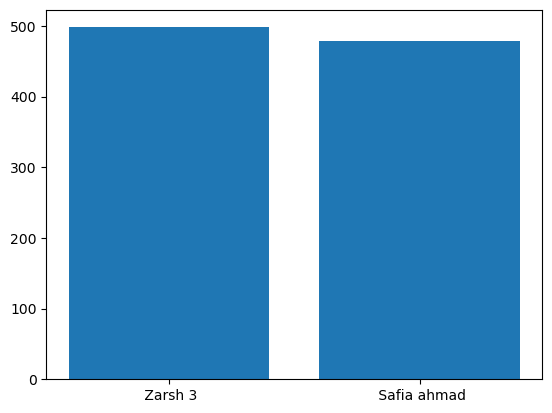

In [85]:
name=x.index
count=x.values
plt.bar(name,count)

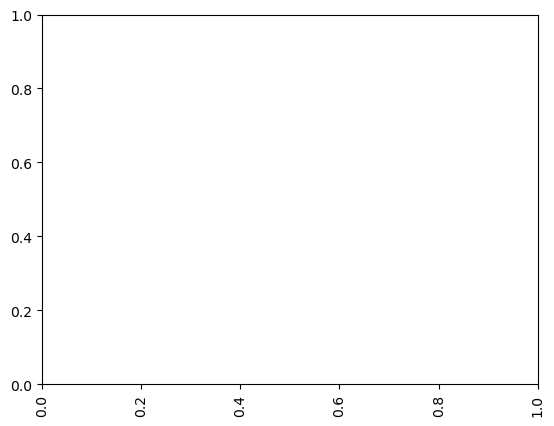

In [89]:
plt.xticks(rotation='vertical')
plt.show()

In [91]:
round((df['user'].value_counts() / df.shape[0]) * 100, 2).reset_index().rename(columns={'index': 'name', 'user': 'percent'})

,percent,count
0,Zarsh 3,51.02
1,Safia ahmad,48.98


In [93]:
words=[]
for message in df['message']:
    words.extend(message.split())
    

In [103]:
from collections import Counter
pd.DataFrame(Counter(words).most_common(20))

,0,1
0,hai,72
1,nhi,36
2,"call,",36
3,h,34
4,i,33
5,to,32
6,tou,24
7,bhi,23
8,acha,22
9,pr,22


In [105]:
temp = df[df['user'] != 'group_notification']

In [107]:
f = open('stop_hinglish.txt', 'r')
stop_words = f.read()
print(stop_words)

.
..
...
?
-
--
1
2
3
4
5
6
7
8
9
0
a
aadi
aaj
aap
aapne
aata
aati
aaya
aaye
ab
abbe
abbey
abe
abhi
able
about
above
accha
according
accordingly
acha
achcha
across
actually
after
afterwards
again
against
agar
ain
aint
ain't
aisa
aise
aisi
alag
all
allow
allows
almost
alone
along
already
also
although
always
am
among
amongst
an
and
andar
another
any
anybody
anyhow
anyone
anything
anyway
anyways
anywhere
ap
apan
apart
apna
apnaa
apne
apni
appear
are
aren
arent
aren't
around
arre
as
aside
ask
asking
at
aur
avum
aya
aye
baad
baar
bad
bahut
bana
banae
banai
banao
banaya
banaye
banayi
banda
bande
bandi
bane
bani
bas
bata
batao
bc
be
became
because
become
becomes
becoming
been
before
beforehand
behind
being
below
beside
besides
best
better
between
beyond
bhai
bheetar
bhi
bhitar
bht
bilkul
bohot
bol
bola
bole
boli
bolo
bolta
bolte
bolti
both
brief
bro
btw
but
by
came
can
cannot
cant
can't
cause
causes
certain
certainly
chahiye
chaiye
chal
chalega
chhaiye
clearly
c'mon
com
come
comes
could
coul

In [109]:
words = []

for message in df['message']:
    for word in message.lower().split():
        if word not in stop_words:
            words.append(word)

In [111]:
from collections import Counter

pd.DataFrame(Counter(words).most_common(20))

,0,1
0,"call,",36
1,tou,28
2,‎voice,22
3,call,16
4,hai‎,12
5,‎you,12
6,deleted,12
7,message.,12
8,back,9
9,‎no,9


In [113]:
!pip install emoji



   ---------------------------------------- 0.0/608.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/608.4 kB ? eta -:--:--
    --------------------------------------- 10.2/608.4 kB ? eta -:--:--
   - ------------------------------------- 20.5/608.4 kB 162.5 kB/s eta 0:00:04
   - ------------------------------------- 30.7/608.4 kB 187.9 kB/s eta 0:00:04
   --- ----------------------------------- 61.4/608.4 kB 328.2 kB/s eta 0:00:02
   --------- ---------------------------- 153.6/608.4 kB 706.2 kB/s eta 0:00:01
   ----------------------- ---------------- 358.4/608.4 kB 1.4 MB/s eta 0:00:01
   ------------------------------- -------- 481.3/608.4 kB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 608.4/608.4 kB 1.7 MB/s eta 0:00:00


In [117]:
import emoji

emojis = []
for message in df['message']:
    emojis.extend([c for c in message if c in emoji.EMOJI_DATA])

In [119]:
pd.DataFrame(Counter(emojis).most_common(len(Counter(emojis))))

,0,1
0,😭,75
1,😔,20
2,💀,16
3,🏻,12
4,😋,6
5,🥹,6
6,👬,6
7,🙏,5
8,🙌,5
9,😂,4
